In [1]:
import blpapi
import pandas as pd

def start_bloomberg_session():
    sessionOptions = blpapi.SessionOptions()
    sessionOptions.setServerHost("localhost")
    sessionOptions.setServerPort(8194)
    
    session = blpapi.Session(sessionOptions)
    if not session.start():
        raise Exception("Failed to start Bloomberg session.")
    if not session.openService("//blp/refdata"):
        raise Exception("Failed to open //blp/refdata service.")
    return session

def get_reference_data(session, tickers, fields):
    refDataService = session.getService("//blp/refdata")
    request = refDataService.createRequest("ReferenceDataRequest")
    
    for ticker in tickers:
        request.getElement("securities").appendValue(ticker)
    for field in fields:
        request.getElement("fields").appendValue(field)
        
    session.sendRequest(request)
    
    data = []
    while True:
        event = session.nextEvent(500)
        if event.eventType() in (blpapi.Event.PARTIAL_RESPONSE, blpapi.Event.RESPONSE):
            for msg in event:
                securityDataArray = msg.getElement("securityData")
                for i in range(securityDataArray.numValues()):
                    securityData = securityDataArray.getValueAsElement(i)
                    ticker = securityData.getElementAsString("security")
                    fieldData = securityData.getElement("fieldData")
                    
                    row = {"ticker": ticker}
                    for field in fields:
                        if fieldData.hasElement(field):
                            try:
                                row[field] = fieldData.getElementAsFloat(field)
                            except:
                                row[field] = fieldData.getElementAsString(field)
                        else:
                            row[field] = None
                    data.append(row)
        if event.eventType() == blpapi.Event.RESPONSE:
            break
            
    return pd.DataFrame(data)

# Define tickers and fields
tickers = [
    "INTC US Equity", # Intel
    "AMD US Equity",  # AMD
    "NVDA US Equity", # NVIDIA
    "TSM US Equity",  # TSMC
    "QCOM US Equity", # Qualcomm
    "TXN US Equity",  # Texas Instruments
    "AVGO US Equity"  # Broadcom
]

fields = [
    "NAME",
    "CUR_MKT_CAP",        # Market Cap
    "PE_RATIO",           # Trailing P/E
    "BEST_PE_RATIO",      # Forward P/E
    "EV_TO_T12M_EBITDA",  # EV/EBITDA
    "PX_TO_BOOK_RATIO",   # Price to Book
    "EQY_DIV_YLD_IND"     # Dividend Yield
]

print("Starting Bloomberg session...")
session = start_bloomberg_session()

print("Fetching data...")
df_valuation = get_reference_data(session, tickers, fields)

print("Stopping session...")
session.stop()

# Set Ticker as index and show the table
df_valuation.set_index("ticker", inplace=True)
df_valuation

Starting Bloomberg session...
Fetching data...


Stopping session...


,NAME,CUR_MKT_CAP,PE_RATIO,BEST_PE_RATIO,EV_TO_T12M_EBITDA,PX_TO_BOOK_RATIO,EQY_DIV_YLD_IND
ticker,,,,,,,
INTC US Equity,INTEL CORP,4.148460e+11,328.839385,78.015123,32.869503,3.721910,None
AMD US Equity,ADVANCED MICRO DEVICES,5.670481e+11,136.785084,51.550319,51.318110,8.999036,None
NVDA US Equity,NVIDIA CORP,5.060961e+12,45.099758,25.138202,33.734415,32.180670,None
TSM US Equity,TAIWAN SEMICONDUCTOR-SP ADR,2.087361e+12,NaN,24.378740,15.111386,NaN,None
QCOM US Equity,QUALCOMM INC,1.588229e+11,15.271517,14.527621,13.897336,6.928657,None
TXN US Equity,TEXAS INSTRUMENTS INC,2.522231e+11,47.515609,35.783086,21.523006,15.031435,None
AVGO US Equity,BROADCOM INC,2.001628e+12,74.957183,31.724448,44.358934,25.067501,None


C:\Users\nklannfonteyne1\AppData\Local\Temp\ipykernel_22012\798917932.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_sorted_pe.index.str.split(' ').str[0], y='BEST_PE_RATIO', data=df_sorted_pe,
C:\Users\nklannfonteyne1\AppData\Local\Temp\ipykernel_22012\798917932.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df_sorted_ev.index.str.split(' ').str[0], y='EV_TO_T12M_EBITDA', data=df_sorted_ev,


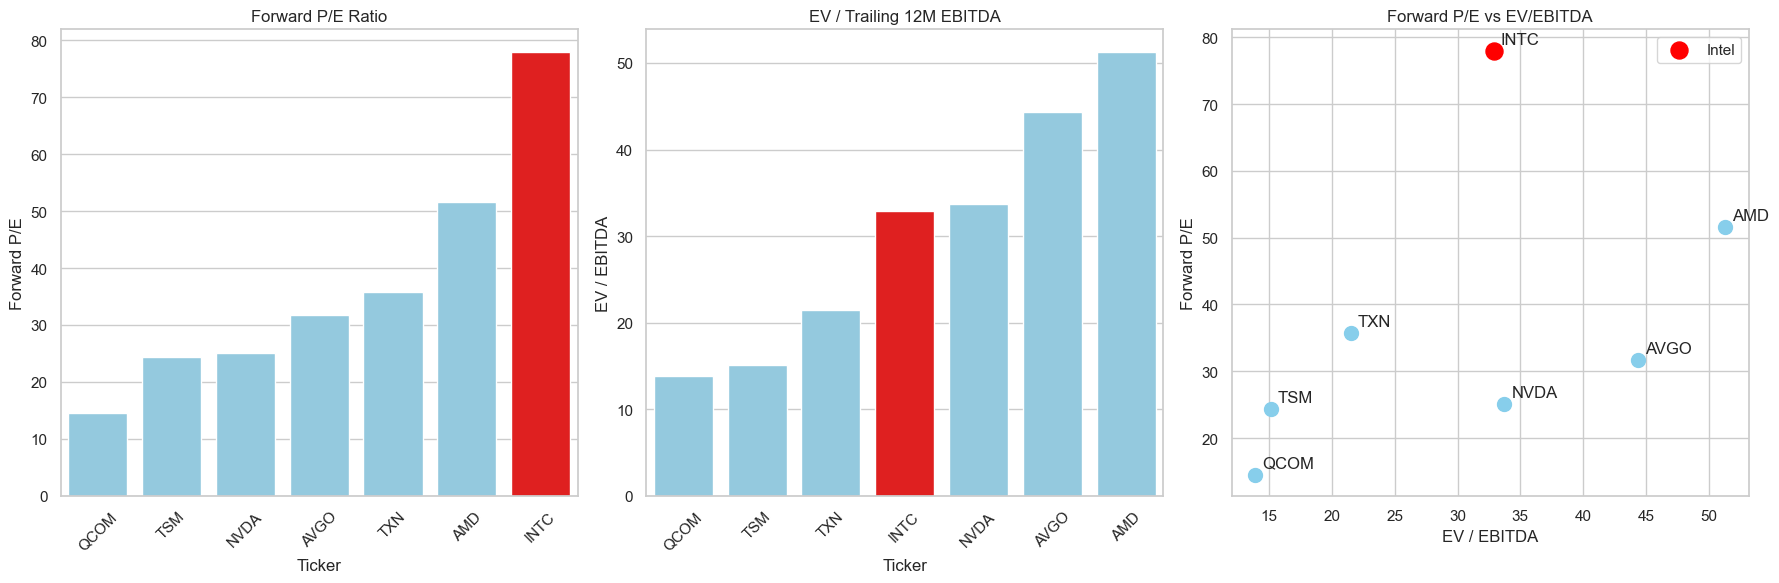

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the visual style
sns.set_theme(style="whitegrid")

# Create a figure with 3 subplots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Plot 1: Forward P/E
# Sort values for better visualization
df_sorted_pe = df_valuation.dropna(subset=['BEST_PE_RATIO']).sort_values('BEST_PE_RATIO')
colors_pe = ['red' if x == 'INTC US Equity' else 'skyblue' for x in df_sorted_pe.index]

sns.barplot(x=df_sorted_pe.index.str.split(' ').str[0], y='BEST_PE_RATIO', data=df_sorted_pe, 
            ax=axes[0], palette=colors_pe)
axes[0].set_title('Forward P/E Ratio')
axes[0].set_ylabel('Forward P/E')
axes[0].set_xlabel('Ticker')
axes[0].tick_params(axis='x', rotation=45)

# Plot 2: EV/EBITDA
df_sorted_ev = df_valuation.dropna(subset=['EV_TO_T12M_EBITDA']).sort_values('EV_TO_T12M_EBITDA')
colors_ev = ['red' if x == 'INTC US Equity' else 'skyblue' for x in df_sorted_ev.index]

sns.barplot(x=df_sorted_ev.index.str.split(' ').str[0], y='EV_TO_T12M_EBITDA', data=df_sorted_ev, 
            ax=axes[1], palette=colors_ev)
axes[1].set_title('EV / Trailing 12M EBITDA')
axes[1].set_ylabel('EV / EBITDA')
axes[1].set_xlabel('Ticker')
axes[1].tick_params(axis='x', rotation=45)

# Plot 3: Scatter Plot EV/EBITDA vs Forward P/E
axes[2].scatter(df_valuation['EV_TO_T12M_EBITDA'], df_valuation['BEST_PE_RATIO'], color='skyblue', s=100)

# Highlight Intel
intel_data = df_valuation.loc['INTC US Equity']
axes[2].scatter(intel_data['EV_TO_T12M_EBITDA'], intel_data['BEST_PE_RATIO'], color='red', s=150, zorder=5, label='Intel')

# Add labels to points
for i, txt in enumerate(df_valuation.index):
    ticker = txt.split(' ')[0]
    x = df_valuation['EV_TO_T12M_EBITDA'].iloc[i]
    y = df_valuation['BEST_PE_RATIO'].iloc[i]
    if pd.notna(x) and pd.notna(y):
        axes[2].annotate(ticker, (x, y), xytext=(5, 5), textcoords='offset points')

axes[2].set_title('Forward P/E vs EV/EBITDA')
axes[2].set_xlabel('EV / EBITDA')
axes[2].set_ylabel('Forward P/E')
axes[2].legend()

plt.tight_layout()
plt.show()

### Relative Value Analysis: Intel vs. Semiconductor Peers

**1. Earnings Multiples (P/E and Forward P/E)**
*   **Intel (INTC)** is trading at an extraordinarily high Forward P/E of **~78.0x**, which is the highest among its peer group. 
*   For comparison, high-growth peers like **NVIDIA (NVDA)** and **TSMC (TSM)** are trading at Forward P/E ratios of **~25.1x** and **~24.3x**, respectively. 
*   **AMD** sits at ~51.5x, which is lower than Intel but higher than the rest of the group.
*   *Takeaway:* Intel's extremely high P/E multiples are largely a result of heavily depressed earnings estimates rather than premium growth expectations. Because earnings are near the bottom of their cycle, traditional P/E ratios make Intel look highly overvalued compared to fundamentally stronger peers.

**2. Enterprise Value to EBITDA (EV/EBITDA)**
*   On an **EV/EBITDA** basis, Intel looks slightly more reasonable at **~32.8x**.
*   This metric puts Intel roughly in line with NVIDIA (~33.7x) and significantly cheaper than AMD (~51.3x) and Broadcom (~44.3x).
*   *Takeaway:* The discrepancy between Intel's sky-high P/E and moderate EV/EBITDA suggests that Intel has massive depreciation and amortization expenses (stemming from its capital-intensive fab build-outs) that drag down net income but are added back in EBITDA.

**3. Price to Book (P/B)**
*   Intel trades at a **P/B of 3.7x**, which is the lowest in the group (e.g., NVDA is at ~32.1x, AVGO at ~25.0x).
*   *Takeaway:* From an asset value perspective, Intel is priced much closer to its book value than its peers. This reflects the market's current skepticism regarding Intel's ability to generate high returns on its massive fab investments.

**Conclusion**
Intel is a unique case in the semiconductor space right now. On an earnings basis (P/E), it screens as the most expensive stock in the peer group due to collapsed near-term profitability. However, on an asset basis (P/B) and operating cash flow proxy basis (EV/EBITDA), it is priced much closer to the middle or bottom of the pack. The valuation reflects a heavily capitalized "turnaround story" rather than a steady-state business.